## Load in Test Case & Run Power Flow

In [1]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets
disturbance_profile_dir = project_dir / "disturbance_profiles" # disturbance profiles for ANDES perturbation
out_dir = project_dir / "out"
pert_path = project_dir / "2_noise_pert.py"

In [2]:
from calculate_metrics import calculate_metrics

In [3]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import andes

andes.config_logger(stream_level=30)

In [4]:
# import case file
case_path = andes.get_case(test_case_dir / "regf2_testbench.xlsx")

In [5]:
# TDS Constants
STEP_TIME = 0.01 # 10 ms

In [7]:
ss_true = andes.load(case_path, setup=False)

ss_true.setup()
ss_true.config.warn_abnormal = 0
ss_true.PFlow.run()
#ss_true.REGF2.set("Tr",1,0.01)


ss_true.TDS.config.tf = 10 # Baruzzi et al ran simulation for 9s after disturbance
ss_true.TDS.config.fixt = 1 # fixed step size
ss_true.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss_true.TDS.config.no_tqdm = 1
ss_true.TDS.config.criteria = 1
ss_true.TDS.run()

True

## Run TDS & Initial Results

In [13]:
ss = andes.load(case_path, pert=pert_path)
#ss.REGF2.set("Tr",1,0.01)
print(ss.REGF2.Tr.v)

ss.setup()
ss.config.warn_abnormal = 0
ss.PFlow.run()

ss.TDS.config.tf = 10 # Baruzzi et al ran simulation for 9s after disturbance
ss.TDS.config.fixt = 1 # fixed step size
ss.TDS.config.tstep = STEP_TIME # matches Baruzzi et al. 

ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 1
ss.TDS.run()

[0.005]
pert() applied at grid_t=0.0
Old value: 0.2
Psen_y_noise: 0.1749427369739183
state: {'last_t': None, 'ou_vd': np.float64(0.0007520035539294849), 'ou_vq': np.float64(-0.002566550403257001), 'ou_id': np.float64(0.001852019475744141), 'ou_iq': np.float64(0.0023211958121838253), 'last_grid_t': 0.0}
pert() applied at grid_t=0.01
Old value: 0.19999997191876193
Psen_y_noise: 0.17460476585478554
state: {'last_t': None, 'ou_vd': np.float64(-0.0040995823587442375), 'ou_vq': np.float64(-0.005654994046587318), 'ou_id': np.float64(0.0020771895091999744), 'ou_iq': np.float64(0.0014275426823996229), 'last_grid_t': 0.01}
pert() applied at grid_t=0.02
Old value: 0.19995797756430891
Psen_y_noise: 0.1765867333322915
state: {'last_t': None, 'ou_vd': np.float64(-0.0039411065183526765), 'ou_vq': np.float64(-0.007484402209355088), 'ou_id': np.float64(0.004146127743283653), 'ou_iq': np.float64(0.0032774135979649907), 'last_grid_t': 0.02}
pert() applied at grid_t=0.03
Old value: 0.19986841459582133
Pse

System has been setup. Calling setup() twice is not allowed. To add devices, reload the case with setup=False, add devices, then call setup().


pert() applied at grid_t=0.19
Old value: 0.1955213764509358
Psen_y_noise: 0.17255563752039882
state: {'last_t': None, 'ou_vd': np.float64(-0.006136762334510465), 'ou_vq': np.float64(-0.00042519578964090134), 'ou_id': np.float64(0.005032963188822278), 'ou_iq': np.float64(0.0037573442706118373), 'last_grid_t': 0.19}
pert() applied at grid_t=0.2
Old value: 0.19587138672571264
Psen_y_noise: 0.17223361103746657
state: {'last_t': None, 'ou_vd': np.float64(-0.004710204878163559), 'ou_vq': np.float64(-0.0020380089907279407), 'ou_id': np.float64(0.00389153129623357), 'ou_iq': np.float64(0.002632015159922652), 'last_grid_t': 0.2}
pert() applied at grid_t=0.21
Old value: 0.19643245772557938
Psen_y_noise: 0.17094248137152254
state: {'last_t': None, 'ou_vd': np.float64(-0.0074316678120740255), 'ou_vq': np.float64(-0.0007368270829837382), 'ou_id': np.float64(0.002543312943339481), 'ou_iq': np.float64(0.002534484184625164), 'last_grid_t': 0.21}
pert() applied at grid_t=0.22
Old value: 0.1969421501283

True

In [14]:
def visualize_cf_noise(noisy, true, var, figsize=(6,4)):
    fig, ax = plt.subplots(figsize=figsize)

    ax.set_title(f"{var}: Noisy vs. Noiseless Signal Inputs")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(f"{var} (p.u.)")

    # plot actual
    ax.plot(noisy.index, noisy, "s-", color="tab:orange",
                    markersize=0.5, label="Noisy Inputs", alpha=1)
    ax.plot(true.index, true, "s-", color="tab:blue",
            markersize=0.5, label="Noiseless Inputs", alpha=0.6)
    

    ax.legend(loc="lower right", fontsize=9, framealpha=0.9)


    plt.tight_layout()

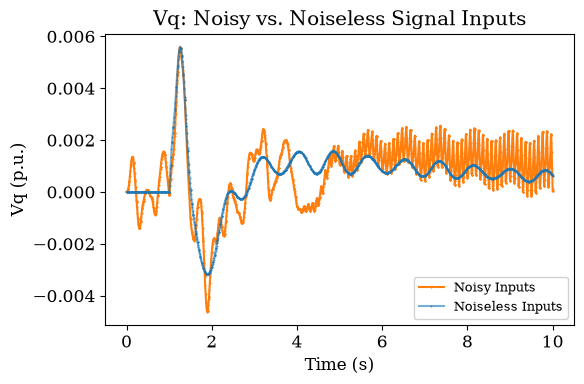

In [15]:
vq = ss.TDS.get_timeseries(ss.REGF2.vq)
vq_t = ss_true.TDS.get_timeseries(ss_true.REGF2.vq)

visualize_cf_noise(vq, vq_t, "Vq")

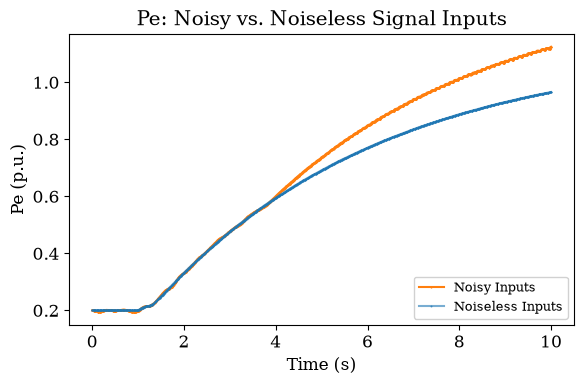

In [16]:
psen = ss.TDS.get_timeseries(ss.REGF2.Pe)
psen_t = ss_true.TDS.get_timeseries(ss_true.REGF2.Pe)

visualize_cf_noise(psen, psen_t, "Pe")

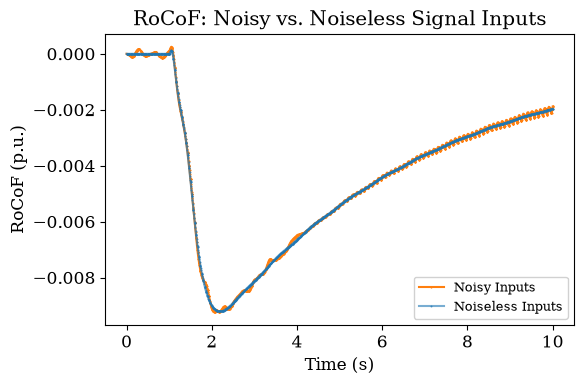

In [38]:
a1 = ss.TDS.get_timeseries(ss.BusROCOF.Wf_y)
a2 = ss_true.TDS.get_timeseries(ss_true.BusROCOF.Wf_y)

visualize_cf_noise(a1, a2, "RoCoF")

## Metrics

In [18]:
metrics_df, h_series = calculate_metrics(ss, True)
metrics_df

,Tr (s),Pref,Peak Inertial Power,Power Available,M_RMSE (s),Max RoCoF,Nadir,Settling Time (s)
0,0.005,0.2,1.12464,1.0,3.939330e+98,0.009224,0.956047,10.0


In [19]:
metrics_true, h_true = calculate_metrics(ss_true, True)

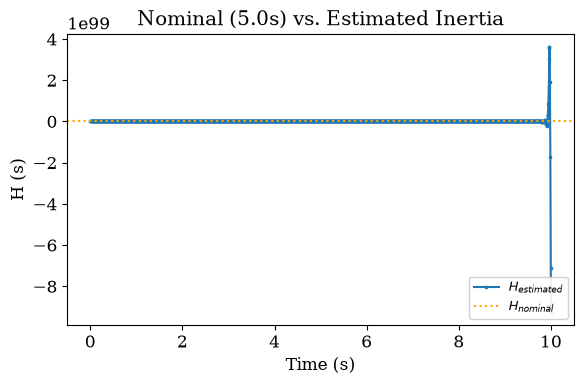

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))

H_gfm = ss.REGF2.get("mf", 1)
H_t = h_series

plot_title = f"Nominal ({H_gfm}s) vs. Estimated Inertia"
ax.set_title(plot_title)
ax.set_xlabel("Time (s)")
ax.set_ylabel("H (s)")

# plot actual
ax.plot(H_t.index, H_t, "s-", color="tab:blue", markersize=1.8, label = f"$H_{{estimated}}$")

plt.axline((0, H_gfm), slope=0, color="orange", linestyle=":", label=f"$H_{{nominal}}$")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)

#ax.axvspan(0, time_invalid, color='gray', alpha=0.2)
#plt.xlim(0, 6)
#plt.ylim(-1, 50)
plt.tight_layout()

#plt.savefig(f'{out_dir}/1_testbench_figs/{plot_title}.png', dpi=300, bbox_inches='tight')

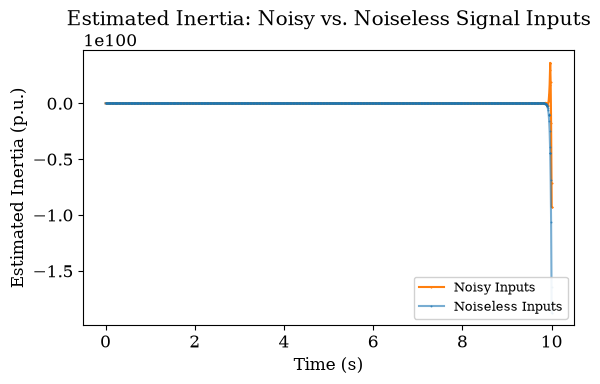

In [21]:
visualize_cf_noise(h_series, h_true, "Estimated Inertia")

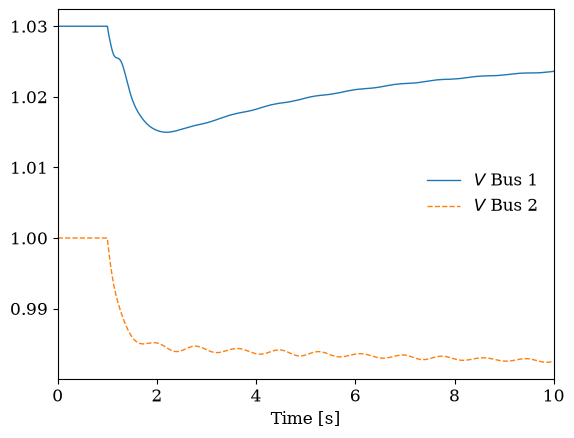

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [26]:
ss_true.TDS.plot(ss.Bus.v)

# Temp

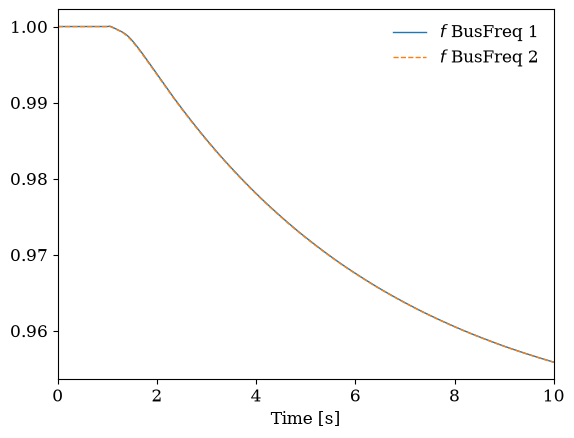

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [36]:
ss_true.TDS.plot(ss_true.BusFreq.f)

In [34]:
metrics_true

,Tr (s),Pref,Peak Inertial Power,Power Available,M_RMSE (s),Max RoCoF,Nadir,Settling Time (s)
0,0.005,0.2,0.96598,1.0,8.233109e+98,0.009209,0.956032,10.0
